# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score)
from dataclasses import dataclass
from numpy.typing import NDArray


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
RANDOM_STATE = 42
SEEDS        = [42, 0, 123, 7, 99, 67, 420, 20, 321, 38]
K_SELECTED = 7 # best on our model 


In [3]:
import csv, time, uuid
from datetime import datetime
from pathlib import Path

EXPERIMENTS_CSV = Path("experiments.csv")
EXPERIMENT_COLS = [
    "run_id", "representation_id", "method", "parameters",
    "seed", "sample_rule", "silhouette", "davies_bouldin",
    "calinski_harabasz", "inertia", "runtime_s", "notes"
]

EXPERIMENTS_CSV.unlink(missing_ok=True)
with open(EXPERIMENTS_CSV, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=EXPERIMENT_COLS).writeheader()

def log_experiment(
    representation_id: str,
    method: str,
    parameters: dict,
    seed,
    sample_rule: str,
    metrics: dict,
    inertia,
    runtime_s: float,
    notes: str = "",
):
    row = {
        "run_id":            datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6],
        "representation_id": representation_id,
        "method":            method,
        "parameters":        str(parameters),
        "seed":              seed,
        "sample_rule":       sample_rule,
        "silhouette":        round(metrics.get("Silhouette",        metrics.get("silhouette", "")), 6),
        "davies_bouldin":    round(metrics.get("Davies-Bouldin",    metrics.get("davies_bouldin", "")), 6),
        "calinski_harabasz": round(metrics.get("Calinski-Harabasz", metrics.get("calinski_harabasz", "")), 4),
        "inertia":           round(inertia, 4) if inertia is not None else "",
        "runtime_s":         round(runtime_s, 4),
        "notes":             notes,
    }
    with open(EXPERIMENTS_CSV, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=EXPERIMENT_COLS).writerow(row)
    return row


# 1. Data Loading

In [4]:
hotel_csv = pd.read_csv("../tables/hotel_bookings_course_release_v1.csv")

In [5]:
df = hotel_csv.copy()
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [6]:
import hashlib

OFFICIAL_SHA256 = '7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06'

dataset_path = "../tables/hotel_bookings_course_release_v1.csv"

with open(dataset_path, 'rb') as f:
    computed_sha256 = hashlib.sha256(f.read()).hexdigest()
    f.seek(0, 2)
    dataset_size = f.tell()

is_valid = computed_sha256 == OFFICIAL_SHA256

print(f"\n File: {dataset_path}")
print(f"   Size: {dataset_size:,} bytes ({dataset_size / (1024**2):.1f} MB)")
print(f"\n SHA-256 Verification:")
print(f"   Official:  {OFFICIAL_SHA256}")
print(f"   Computed:  {computed_sha256}")
print(f"   Status:    {'VALID - Dataset matches Course Release v1' if is_valid else 'MISMATCH - Dataset integrity check FAILED!'}")

if not is_valid:
    raise ValueError(f"Dataset integrity check failed!\n"
                    f"  Expected: {OFFICIAL_SHA256}\n"
                    f"  Got:      {computed_sha256}")

# Store metadata for reproducibility
DATASET_INFO = {
    'path': dataset_path,
    'sha256': computed_sha256,
    'size_bytes': dataset_size,
    'rows_original': len(df),
    'columns': len(df.columns),
    'verification_timestamp': pd.Timestamp.now().isoformat(),
    'release_version': 'Course Release v1',
    'release_date': '2026-02-22'
}

print(f"\n Dataset Metadata:")
print(f"   Rows: {DATASET_INFO['rows_original']:,}")
print(f"   Columns: {DATASET_INFO['columns']}")
print(f"   Release: {DATASET_INFO['release_version']} ({DATASET_INFO['release_date']})")


 File: ../tables/hotel_bookings_course_release_v1.csv
   Size: 16,855,599 bytes (16.1 MB)

 SHA-256 Verification:
   Official:  7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06
   Computed:  7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06
   Status:    VALID - Dataset matches Course Release v1

 Dataset Metadata:
   Rows: 119,390
   Columns: 32
   Release: Course Release v1 (2026-02-22)


# 2. Exploratory Data Analysis (EDA) - Missingness and Outlier Snapshot

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [8]:
miss = df.isnull().sum()
miss = miss[miss > 0]
print('Missing values:')
print(miss)

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64


In [9]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [10]:
#only this variables because others are 

KEY_NUM = ['lead_time','adr','adults','stays_in_week_nights',
           'stays_in_weekend_nights','children','babies',
           'previous_cancellations','previous_bookings_not_canceled',
           'total_of_special_requests', 'booking_changes', 'days_in_waiting_list',
           'required_car_parking_spaces']

print('\nKey numeric descriptives:')
print(df[KEY_NUM].describe().round(2))


Key numeric descriptives:
       lead_time        adr     adults  stays_in_week_nights  stays_in_weekend_nights  children     babies  \
count  119390.00  119390.00  119390.00             119390.00                119390.00  119386.0  119390.00   
mean      104.01     101.83       1.86                  2.50                     0.93       0.1       0.01   
std       106.86      50.54       0.58                  1.91                     1.00       0.4       0.10   
min         0.00      -6.38       0.00                  0.00                     0.00       0.0       0.00   
25%        18.00      69.29       2.00                  1.00                     0.00       0.0       0.00   
50%        69.00      94.58       2.00                  2.00                     1.00       0.0       0.00   
75%       160.00     126.00       2.00                  3.00                     2.00       0.0       0.00   
max       737.00    5400.00      55.00                 50.00                    19.00      10

In [11]:
aux_csv = pd.read_csv("../tables/column_roles.csv")
aux_csv

# Filter to keep only variables with 'exclude' recommendation
excluded_vars = aux_csv[aux_csv['recommended_action'] == 'exclude']
excluded_vars

,column,recommended_action,role,rationale
1,is_canceled,exclude,outcome/post-event,Outcome or post-event attribute; do not use to...
23,agent,exclude,id-like/high-cardinality,Identifier-like field with many unique values;...
24,company,exclude,id-like/high-cardinality,Identifier-like field with many unique values;...
30,reservation_status,exclude,outcome/post-event,Outcome or post-event attribute; do not use to...
31,reservation_status_date,exclude,outcome/post-event,Outcome or post-event attribute; do not use to...


In [12]:
(df['is_repeated_guest'] == 1).sum()

np.int64(3810)

In [13]:
(df['previous_cancellations'] >= 1).sum()

np.int64(6484)

In [14]:
(df['previous_bookings_not_canceled'] >= 1).sum()

np.int64(3620)

In [15]:
(df['required_car_parking_spaces'] > 1).sum()

np.int64(33)

In [16]:
(df['total_of_special_requests'] >= 1).sum()

np.int64(49072)

In [17]:
df[df['children'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [18]:
(df['stays_in_week_nights']).max()

np.int64(50)

In [19]:
df['stays_in_week_nights'].value_counts().sort_index()
"""
50 -> 1
42 -> 1
41 -> 1
40 -> 2 
35 -> 1
34 -> 1
33 -> 1
32 -> 1
30 -> 5
26 -> 1
25 -> 6
24 -> 3
22 -> 7
21 -> 15
20 -> 41
19 -> 44
18 -> 6
17 -> 4
16 -> 16
15 -> 85
14 -> 35
13 -> 27
12 -> 42
11 -> 56
10 -> 1036
9 -> 231
8 -> 656
7 -> 1029
6 -> 1499
5 -> 11077
4 -> 9563
3 -> 22258
2 -> 33684
1 -> 30310
0 -> 7645
"""



'\n50 -> 1\n42 -> 1\n41 -> 1\n40 -> 2 \n35 -> 1\n34 -> 1\n33 -> 1\n32 -> 1\n30 -> 5\n26 -> 1\n25 -> 6\n24 -> 3\n22 -> 7\n21 -> 15\n20 -> 41\n19 -> 44\n18 -> 6\n17 -> 4\n16 -> 16\n15 -> 85\n14 -> 35\n13 -> 27\n12 -> 42\n11 -> 56\n10 -> 1036\n9 -> 231\n8 -> 656\n7 -> 1029\n6 -> 1499\n5 -> 11077\n4 -> 9563\n3 -> 22258\n2 -> 33684\n1 -> 30310\n0 -> 7645\n'

In [20]:
df['adr'].value_counts().sort_index()

adr
-6.38          1
 0.00       1959
 0.26          1
 0.50          1
 1.00         15
            ... 
 450.00        1
 451.50        1
 508.00        1
 510.00        1
 5400.00       1
Name: count, Length: 8879, dtype: int64

In [21]:
df['adr'].mean()

np.float64(101.83112153446687)

In [22]:
(df['adr'] <= 200).sum()

np.int64(114461)

In [23]:
#will use this one because is where we lost the minimum amount of data
((df['adr'] >= 300) & (df['adr'] <= 5500)).sum()

np.int64(290)

In [24]:
#need to apply logarithm 
(df['previous_cancellations'] > 25).sum()

np.int64(26)

In [25]:
#need to apply logarithm
(df['previous_bookings_not_canceled'] > 25).sum()

np.int64(80)

lead_time: skew 1.35 -> -0.87  [APLICAR]
previous_cancellations: skew 24.46 -> 7.35  [APLICAR]
previous_bookings_not_canceled: skew 23.54 -> 8.17  [APLICAR]


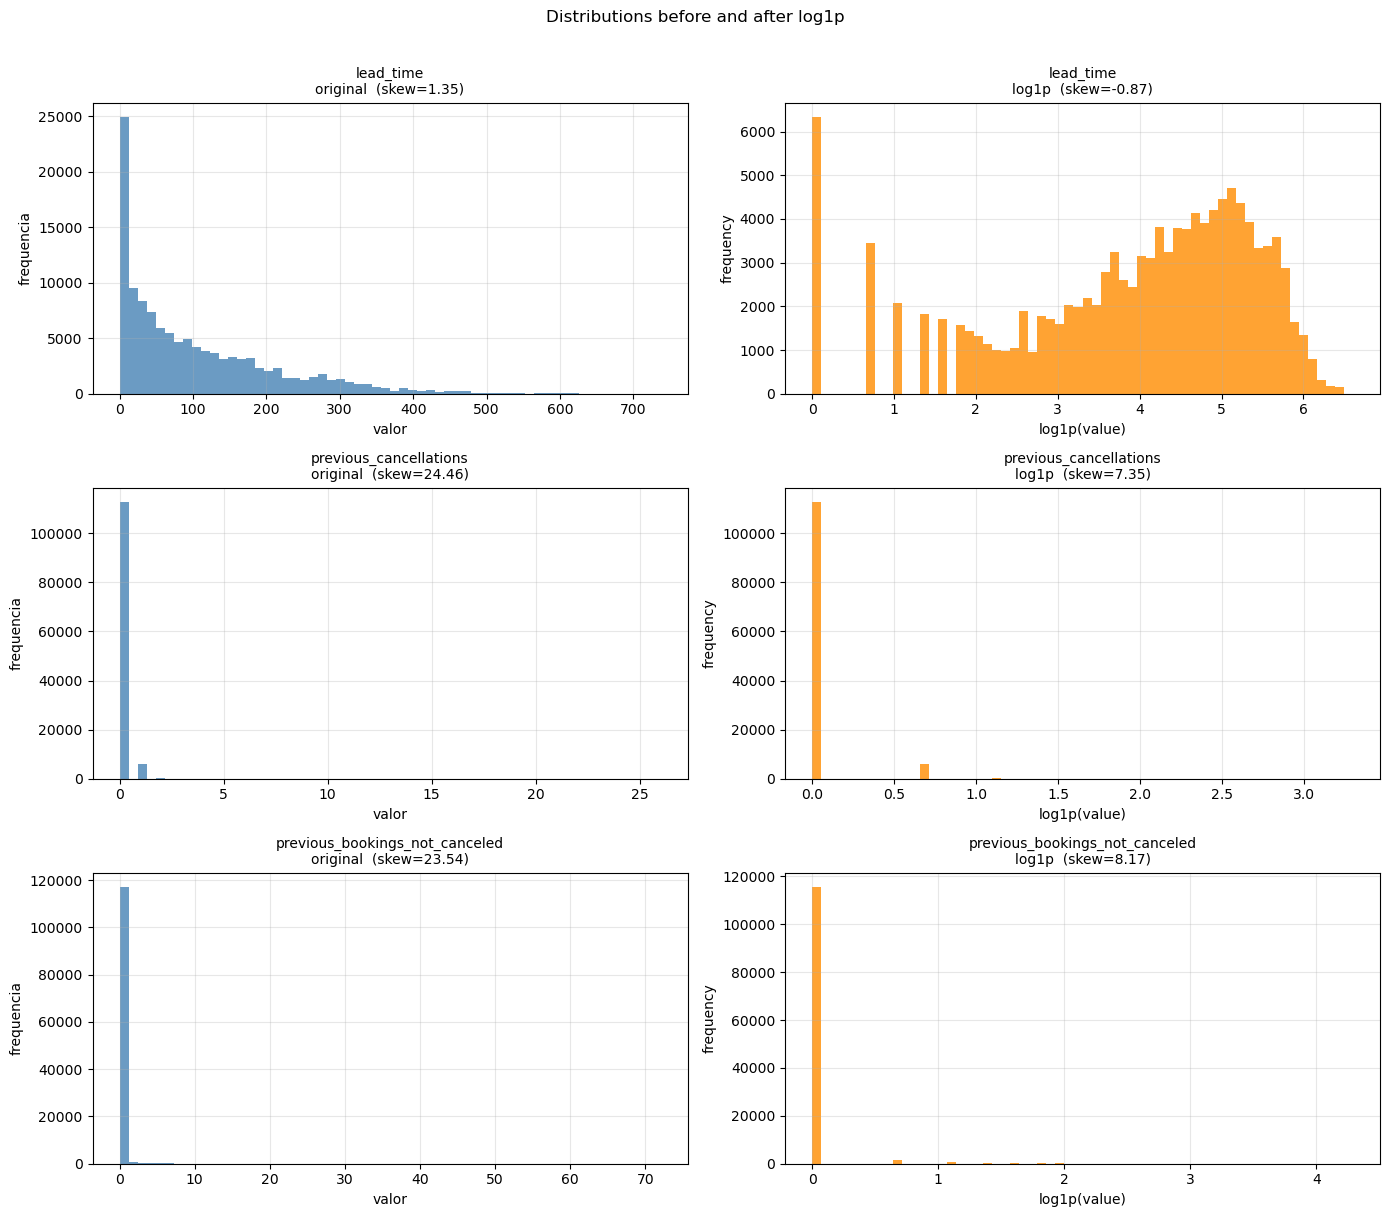

In [26]:
LOG_COLS = ['lead_time', 'previous_cancellations',
            'previous_bookings_not_canceled']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(LOG_COLS):
    raw   = df[col].dropna()
    transformed = np.log1p(raw)

    sk_before = raw.skew()
    sk_after  = transformed.skew()

    # before
    ax = axes[i, 0]
    ax.hist(raw, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'{col}\noriginal  (skew={sk_before:.2f})', fontsize=10)
    ax.set_xlabel('valor'); ax.set_ylabel('frequencia')
    ax.grid(True, alpha=0.3)

    # after
    ax = axes[i, 1]
    ax.hist(transformed, bins=60, color='darkorange', edgecolor='none', alpha=0.8)
    ax.set_title(f'{col}\nlog1p  (skew={sk_after:.2f})', fontsize=10)
    ax.set_xlabel('log1p(value)'); ax.set_ylabel('frequency')
    ax.grid(True, alpha=0.3)

    # eligibility verdict
    melhora = abs(sk_after) < abs(sk_before)
    print(f'{col}: skew {sk_before:.2f} -> {sk_after:.2f}  '
          f'[{"APLICAR" if melhora else "NAO APLICAR"}]')

plt.suptitle('Distributions before and after log1p', fontsize=12, y=1.01)
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/log_transforms.png', dpi=150, bbox_inches='tight')
plt.show()

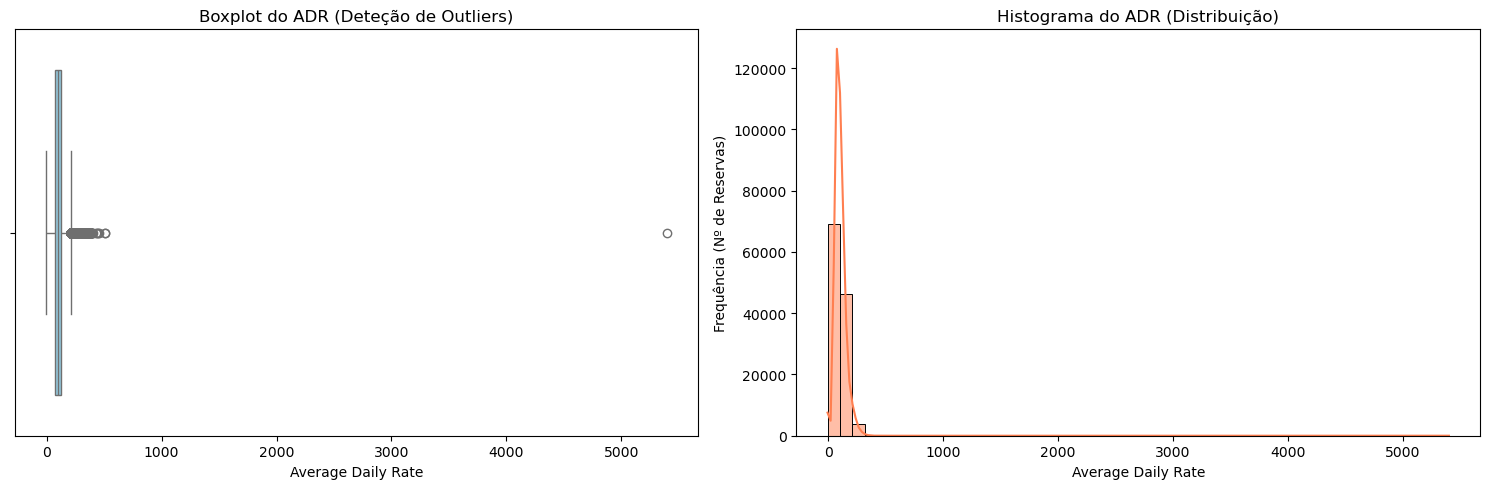

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df['adr'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot do ADR (Deteção de Outliers)')
axes[0].set_xlabel('Average Daily Rate')

#Price Concentration
sns.histplot(df['adr'], bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Histograma do ADR (Distribuição)')
axes[1].set_xlabel('Average Daily Rate')
axes[1].set_ylabel('Frequência (Nº de Reservas)')

fig.savefig('../figures/adr_analysis.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 3. Variable Role Classification

Every variable is assigned to exactly one role before modelling.

| Role | Used in clustering? | Purpose |
|---|---|---|
| **excluded** | No | Post-event outcome / ID / temporal |
| **clustering_input** | Yes | Characterises the booking record at reservation time |
| **profiling** | No | Describes clusters post-hoc (never cluster-forming) |

### 3.1. Feature Selection Table

In [28]:
FEATURE_TABLE = pd.DataFrame([
    # excluded
    dict(variable='is_canceled', role='excluded', reason='Post-event outcome, not known at booking time', transformation='NaN'),
    dict(variable='reservation_status', role='excluded',reason='Post-event outcome', transformation='NaN'),
    dict(variable='reservation_status_date', role='excluded', reason='Post-event outcome', transformation='NaN'),
    dict(variable='agent', role='excluded', reason='ID-like / high-cardinality', transformation='NaN'),
    dict(variable='company', role='excluded', reason='ID-like / high-cardinality', transformation='NaN'),
    dict(variable='arrival_date_year', role='excluded', reason='Temporal context', transformation='NaN'),
    dict(variable='arrival_date_month', role='excluded', reason='Temporal context', transformation='NaN'),
    dict(variable='arrival_date_week_number', role='excluded', reason='Temporal context', transformation='NaN'),
    dict(variable='arrival_date_day_of_month', role='excluded', reason='Temporal context', transformation='NaN'),
    dict(variable='country', role='excluded', reason='High-cardinality', transformation='NaN'),
    dict(variable='assigned_room_type', role='excluded', reason='Assigned post-booking', transformation='NaN'),
    dict(variable='booking_changes', role='excluded', reason='Recorded after booking', transformation='NaN'),
    dict(variable='days_in_waiting_list', role='excluded', reason='Determined post-booking', transformation='NaN'),
    
    # clustering inputs
    dict(variable='hotel', role='clustering_input', reason='Product type selected at booking time', transformation='profiling (nOT IN CATEGORICAL_BASE)'),
    dict(variable='lead_time', role='clustering_input', reason='Planning horizon of the booking', transformation='log1p then StandardScaler(R0,R2) / RobustScaler(R1)'),
    dict(variable='total_nights [derived]', role='clustering_input', reason='week_nights + weekend_nights', transformation='StandardScaler(R0,R2) / RobustScaler(R1)'),
    dict(variable='party_size [derived]', role='clustering_input', reason='adults + children + babies', transformation='StandardScaler(R0,R2) / RobustScaler(R1)'),
    dict(variable='has_kids [derived]', role='clustering_input', reason='Binary flag: children or babies present', transformation='keep 0/1, no scaling (binary pipeline)'),
    dict(variable='needs_parking [derived]',   role='clustering_input', reason='Binary flag: parking space requested', transformation='profiling (IS IN PROFILING_VARS)'),
    dict(variable='is_repeated_guest', role='clustering_input', reason='Account history flag at booking time', transformation='StandardScaler(R0,R2) / RobustScaler(R1)'),
    dict(variable='previous_cancellations',    role='clustering_input', reason='Cancellation history at booking time', transformation='Built degenerated cluster'),
    dict(variable='previous_bookings_not_canceled', role='clustering_input', reason='Completed-booking history at time of booking', transformation='profiling (97% zero) bulit degenerated cluster'),
    dict(variable='market_segment', role='clustering_input', reason='Acquisition channel of the booking', transformation='OneHotEncoder'),
    dict(variable='customer_type', role='clustering_input', reason='Contractual classification of the booking', transformation='OneHotEncoder'),
    dict(variable='deposit_type', role='clustering_input',reason='Payment commitment of the booking', transformation='OneHotEncoder'),
    dict(variable='meal', role='clustering_input', reason='Service package selected at booking time', transformation='OneHotEncoder'),
    dict(variable='total_of_special_requests', role='clustering_input', reason='Number of special requests at booking time', transformation='StandardScaler(R0,R2) / RobustScaler(R1)'),
    
    # profiling
    dict(variable='adr', role='profiling', reason='Price shaped by availability/policy; tested as input in R2', transformation='post-hoc only in R0/R1; StandardScaler in R2'),
    
    # candidates
    dict(variable='distribution_channel', role='cluster_input_candidate',  reason='Booking channel, correlated with market_segment; tested in S10', transformation='OneHotEncoder (Exp A)'),
    dict(variable='reserved_room_type', role='cluster_input_candidate', reason='Room type requested -- tested in S10',transformation='OneHotEncoder (Exp B)'),
])

print(FEATURE_TABLE[['variable','role','transformation']].to_string(index=False))



                      variable                    role                                      transformation
                   is_canceled                excluded                                                 NaN
            reservation_status                excluded                                                 NaN
       reservation_status_date                excluded                                                 NaN
                         agent                excluded                                                 NaN
                       company                excluded                                                 NaN
             arrival_date_year                excluded                                                 NaN
            arrival_date_month                excluded                                                 NaN
      arrival_date_week_number                excluded                                                 NaN
     arrival_date_day_of_month       

# 4. Preprocessing Rules


Every variable is assigned to exactly one role before modelling.

| Role | Used in clustering? | Purpose |
|---|---|---|
| **excluded** | No | Post-event outcome / ID / temporal |
| **clustering_input** | Yes | Characterises the booking record at reservation time |
| **profiling** | No | Describes clusters post-hoc -- never cluster-forming |

In [29]:
df_clustering = df.copy()

# fill children Nan with 0
df_clustering['children'] = df_clustering['children'].fillna(0)

# impossible to make reservations without a adult
df_clustering['adults'] = df_clustering['adults'].replace(0, 1)

# drop negative vals of adr
df_clustering.drop(df_clustering[df_clustering['adr'] < 0].index, inplace=True)

# drop extrem vals of adr
df_clustering.drop(df_clustering[df_clustering['adr'] > 600].index, inplace=True)

# meal: undefined -> BB - for being the most common one 
df_clustering['meal'] = df_clustering['meal'].replace('Undefined', 'BB')

# deposit type: Refundable -> No Deposit - "same"
df_clustering['deposit_type'] = df_clustering['deposit_type'].replace('Refundable', 'No Deposit')

# market segment: very small nums of complementary and aviation so merge it into a 'Other' category
df_clustering['market_segment'] = df_clustering['market_segment'].replace({'Complementary': 'Other', 'Aviation': 'Other'})
df_clustering = df_clustering[df_clustering['market_segment'] != 'Undefined'].copy()

# customer type: Group -> Transient-Party - "same"
df_clustering['customer_type'] = df_clustering['customer_type'].replace('Group', 'Transient-Party')

# feature engineering:
# merge children and babies into single boolean column 'has_kids' 
# required_car_parking_spaces column into into boolean column 'needs_parking' 
df_clustering['has_kids']      = ((df_clustering['children'] + df_clustering['babies']) > 0).astype(int)
df_clustering['needs_parking'] = (df_clustering['required_car_parking_spaces'] > 0).astype(int)

df_clustering['total_nights'] = (df_clustering['stays_in_week_nights'] + df_clustering['stays_in_weekend_nights'])
df_clustering['party_size']   = (df_clustering['adults'] + df_clustering['children'] + df_clustering['babies'])

df_clustering['weekend_share'] = (df_clustering['stays_in_weekend_nights'] / df_clustering['total_nights'].apply(lambda x: max(x, 0.01)))

#logarithm applied to raw values may dominate distance
LOG_COLS = ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']

for col in LOG_COLS:
    df_clustering[col] = np.log1p(df_clustering[col])

print('Log-transformed columns:')
print(df_clustering[LOG_COLS].describe().round(3))

print(f'\ntotal_nights : {df_clustering["total_nights"].min()} -- {df_clustering["total_nights"].max()}')
print(f'party_size   : {df_clustering["party_size"].min()} -- {df_clustering["party_size"].max()}')
print(f'weekend_share   : {df_clustering["weekend_share"].min()} -- {df_clustering["weekend_share"].max()}')


print('\n')
print('\n')
print(f'Hotel distribution:')
print(df_clustering['hotel'].value_counts())


print('\n')
print('\n')
df_clustering.info()
df_clustering

Log-transformed columns:
        lead_time  previous_cancellations  previous_bookings_not_canceled
count  119386.000              119386.000                      119386.000
mean        3.840                   0.043                           0.040
std         1.610                   0.201                           0.262
min         0.000                   0.000                           0.000
25%         2.944                   0.000                           0.000
50%         4.248                   0.000                           0.000
75%         5.081                   0.000                           0.000
max         6.604                   3.296                           4.290

total_nights : 0 -- 69
party_size   : 1.0 -- 55.0
weekend_share   : 0.0 -- 1.0




Hotel distribution:
hotel
City Hotel      79327
Resort Hotel    40059
Name: count, dtype: int64




<class 'pandas.DataFrame'>
Index: 119386 entries, 0 to 119389
Data columns (total 37 columns):
 #   Column                   

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_kids,needs_parking,total_nights,party_size,weekend_share
0,Resort Hotel,0,5.837730,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0.0,0.0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,0,0,0,2.0,0.000000
1,Resort Hotel,0,6.603944,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0.0,0.0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,0,0,0,2.0,0.000000
2,Resort Hotel,0,2.079442,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0.0,0.0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,0,0,1,1.0,0.000000
3,Resort Hotel,0,2.639057,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0.0,0.0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,0,0,1,1.0,0.000000
4,Resort Hotel,0,2.708050,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0.0,0.0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,0,0,2,2.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,3.178054,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0.0,0.0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06,0,0,7,2.0,0.285714
119386,City Hotel,0,4.634729,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0.0,0.0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07,0,0,7,3.0,0.285714
119387,City Hotel,0,3.555348,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0.0,0.0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07,0,0,7,2.0,0.285714
119388,City Hotel,0,4.700480,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0.0,0.0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07,0,0,7,2.0,0.285714


# 5. Feature Sets and Pipelines

| ID | Scaler | ADR as clustering input | Purpose |
|---|---|---|---|
| **R0** | StandardScaler | No (profiling only) | Baseline |
| **R1** | RobustScaler | No | Tests scaler robustness to outliers |
| **R2** | StandardScaler | Yes | Tests price-sensitivity separation |

In [30]:
"""
NUMERIC_BASE = [
    'lead_time', 'total_nights', 'adults', 
    'has_kids', 'needs_parking', 'is_repeated_guest',  
    'total_of_special_requests'
]

# 2. Função do Preprocessador
def build_preprocessor(num_feats):
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    return ColumnTransformer([('num', numeric_transformer, num_feats)])

# 3. Execução do Preprocessamento (Corrigido para usar a função definida)
preprocessor = build_preprocessor(NUMERIC_BASE)
X_R0 = preprocessor.fit_transform(df_clustering)

# --- LOOP DE TESTES (O seu já estava bom) ---
SEEDS = [42] # Adicione mais sementes se quiser maior robustez
K_RANGE = range(3, 9)
k_results = []

for k in K_RANGE:
    sils, inertias = [], []
    for seed in SEEDS:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        lbl = km.fit_predict(X_R0)
        inertias.append(km.inertia_)
        # Usando sample_size para ser mais rápido
        sils.append(silhouette_score(X_R0, lbl, sample_size=10000, random_state=seed))
    
    k_results.append({'k': k, 'mean_inertia': np.mean(inertias), 'mean_sil': np.mean(sils)})
    print(f'k={k}: inertia={np.mean(inertias):,.0f} sil={np.mean(sils):.4f}')

# 4. APLICAÇÃO FINAL (Onde estava o erro)
K_SELECTED = 4 # Defina aqui o K que você escolheu
final_km = KMeans(n_clusters=K_SELECTED, random_state=42, n_init=10)
clusters_finais = final_km.fit_predict(X_R0)

# 5. Adicionando ao DataFrame
df_clustering['cluster'] = clusters_finais

# --- PROFILING ---
print("\n--- Perfil de Atributos (Média) ---")
print(df_clustering.groupby('cluster')[NUMERIC_BASE].mean())

print("\n--- Perfil Financeiro dos Clusters ---")
adr_profile = df_clustering.groupby('cluster')['adr'].agg(['mean', 'median', 'std', 'count']).reset_index()
adr_profile.columns = ['Cluster', 'Média ADR', 'Mediana ADR', 'Desvio Padrão', 'Total de Reservas']
print(adr_profile)"""

'\nNUMERIC_BASE = [\n    \'lead_time\', \'total_nights\', \'adults\', \n    \'has_kids\', \'needs_parking\', \'is_repeated_guest\',  \n    \'total_of_special_requests\'\n]\n\n# 2. Função do Preprocessador\ndef build_preprocessor(num_feats):\n    numeric_transformer = Pipeline([\n        (\'imputer\', SimpleImputer(strategy=\'median\')),\n        (\'scaler\', StandardScaler())\n    ])\n    return ColumnTransformer([(\'num\', numeric_transformer, num_feats)])\n\n# 3. Execução do Preprocessamento (Corrigido para usar a função definida)\npreprocessor = build_preprocessor(NUMERIC_BASE)\nX_R0 = preprocessor.fit_transform(df_clustering)\n\n# --- LOOP DE TESTES (O seu já estava bom) ---\nSEEDS = [42] # Adicione mais sementes se quiser maior robustez\nK_RANGE = range(3, 9)\nk_results = []\n\nfor k in K_RANGE:\n    sils, inertias = [], []\n    for seed in SEEDS:\n        km = KMeans(n_clusters=k, random_state=seed, n_init=10)\n        lbl = km.fit_predict(X_R0)\n        inertias.append(km.inerti

In [31]:
def build_preprocessor(num_feats, bin_feats, cat_feats, scaler_name='standard'):
    sc = StandardScaler() if scaler_name == 'standard' else RobustScaler()
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', sc)
    ])
    binary_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0))
        # sem scaler — manter 0/1
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([('num', numeric_transformer, num_feats), ('bin', binary_transformer, bin_feats), ('cat', categorical_transformer, cat_feats)])
    
def prepare_clusters(df_in, num_feats, bin_feats, cat_feats, scaler_name='standard'):
    pp = build_preprocessor(num_feats, bin_feats, cat_feats, scaler_name)
    return pp.fit_transform(df_in), pp


#ss is to use 20000 random lines of the dataset to test Silhoutte
def metrics(X, labels, ss=20_000):
    sil = silhouette_score(X, labels, sample_size=ss, random_state=RANDOM_STATE)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    return {'Silhouette': round(sil,4), 'Davies-Bouldin': round(db,4), 'Calinski-Harabasz': round(ch,1)}

In [32]:

NUMERIC_BASE = [
    'lead_time',                       # log1p applied
    'total_nights',
    'party_size',                      # derived
    'total_of_special_requests'   
]

BINARY_BASE = [
    'has_kids',
    'is_repeated_guest'
]

CATEGORICAL_BASE = ['market_segment', 'customer_type', 'deposit_type']

# check if columns have outliers 
for col in NUMERIC_BASE:
    q99 = df_clustering[col].quantile(0.99)
    print(f'{col}: max={df_clustering[col].max():.1f}, p99={q99:.1f}')
    

#adding the profiling vars only makes the cluster even worst because of dimension
PROFILING_VARS   = ['adr','hotel', 'meal', 'needs_parking']

X_R0, pp_R0 = prepare_clusters(df_clustering, NUMERIC_BASE, BINARY_BASE, CATEGORICAL_BASE, scaler_name='standard')
X_R1, pp_R1 = prepare_clusters(df_clustering, NUMERIC_BASE, BINARY_BASE, CATEGORICAL_BASE, scaler_name='robust')
X_R2, pp_R2 = prepare_clusters(df_clustering, NUMERIC_BASE + ['adr'], BINARY_BASE, CATEGORICAL_BASE, scaler_name='standard')

repr_df = pd.DataFrame([
    {'Repr': 'R0', 'Scaler': 'StandardScaler', 'ADR input': False,
     'Dimensions': X_R0.shape[1], 'Rows': X_R0.shape[0]},
    {'Repr': 'R1', 'Scaler': 'RobustScaler',   'ADR input': False,
     'Dimensions': X_R1.shape[1], 'Rows': X_R1.shape[0]},
    {'Repr': 'R2', 'Scaler': 'StandardScaler', 'ADR input': True,
     'Dimensions': X_R2.shape[1], 'Rows': X_R2.shape[0]},
])
print('Representation record:')
print(repr_df.to_string(index=False))


lead_time: max=6.6, p99=6.1
total_nights: max=69.0, p99=14.0
party_size: max=55.0, p99=4.0
total_of_special_requests: max=5.0, p99=3.0
Representation record:
Repr         Scaler  ADR input  Dimensions   Rows
  R0 StandardScaler      False          17 119386
  R1   RobustScaler      False          17 119386
  R2 StandardScaler       True          18 119386


In [33]:
# K-selection with multiple seeds for stability
K_RANGE  = range(2, 9)
k_results = []

print(f"{'k':>5} {'mean_sil':>12} {'std_sil':>12} {'mean_davies':>14} {'std_davies':>14} {'mean_cals':>14} {'std_cals':>12}")
print("-" * 90)

for k in K_RANGE:
    sils, davies, cals, inertias = [], [], [], []
    
    for seed in SEEDS:
        t0 = time.perf_counter()
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        lbl = km.fit_predict(X_R0)
        t_elapsed = time.perf_counter() - t0
        
        inertias.append(km.inertia_)
        
        m = metrics(X_R0, lbl)
        sils.append(m['Silhouette'])
        davies.append(m['Davies-Bouldin'])
        cals.append(m['Calinski-Harabasz'])
        
        # Log each individual K-Means fit
        log_experiment(
            representation_id="R0",
            method="kmeans",
            parameters={"n_clusters": k, "n_init": 10},
            seed=seed,
            sample_rule="sample_size=10000",
            metrics=m,
            inertia=km.inertia_,
            runtime_s=t_elapsed,
            notes="k-selection sweep"
        )
    
    k_results.append({
        'k': k,
        'mean_sil': np.mean(sils),
        'std_sil': np.std(sils),
        'mean_davies': np.mean(davies),
        'std_davies': np.std(davies),
        'mean_cals': np.mean(cals),
        'std_cals': np.std(cals),
        'mean_inertia': np.mean(inertias),
        'std_inertia': np.std(inertias),
    })
    
    print(f"{k:>5} {np.mean(sils):>12.4f} {np.std(sils):>12.4f} {np.mean(davies):>14.4f} {np.std(davies):>14.4f} {np.mean(cals):>14.1f} {np.std(cals):>12.1f}")

k_df = pd.DataFrame(k_results)

    k     mean_sil      std_sil    mean_davies     std_davies      mean_cals     std_cals
------------------------------------------------------------------------------------------
    2       0.1871       0.0001         2.0016         0.0012        23957.9          0.9
    3       0.2061       0.0000         1.6546         0.0001        25919.5          0.0
    4       0.2145       0.0001         1.4805         0.0000        24496.1          0.0
    5       0.2183       0.0148         1.4471         0.0906        23419.9        429.4
    6       0.2185       0.0033         1.4324         0.0091        22470.1        215.8
    7       0.2341       0.0000         1.3586         0.0000        22409.3          0.0
    8       0.2147       0.0164         1.3899         0.0347        20994.9         96.2


In [34]:
def decide_best_k(k_results):
    ks = [r['k'] for r in k_results]
    votes = {k: 0 for k in ks}

    has_std = k_results[0].get('std_sil') is not None

    # Silhouette penalized by subtracting std (if exists)
    # Calinski penalized by subtracting std
    # Davies-Bouldin penalized by adding std
    if has_std:
        sil_scores = np.array([r['mean_sil'] - r['std_sil'] for r in k_results])
        cal_scores = np.array([r['mean_cals'] - r['std_cals'] for r in k_results])
        dav_scores = np.array([r['mean_davies'] + r['std_davies'] for r in k_results])
    else:
        sil_scores = np.array([r['mean_sil'] for r in k_results])
        cal_scores = np.array([r['mean_cals'] for r in k_results])
        dav_scores = np.array([r['mean_davies'] for r in k_results])

    best_sil_k = ks[np.argmax(sil_scores)]
    best_cal_k = ks[np.argmax(cal_scores)]
    best_dav_k = ks[np.argmin(dav_scores)]

    votes[best_sil_k] += 1
    votes[best_cal_k] += 1
    votes[best_dav_k] += 1

    best_k = max(votes, key=votes.get)

    return best_k, votes, {
        'silhouette_winner':     best_sil_k,
        'calinski_winner':       best_cal_k,
        'davies_bouldin_winner': best_dav_k,
    }

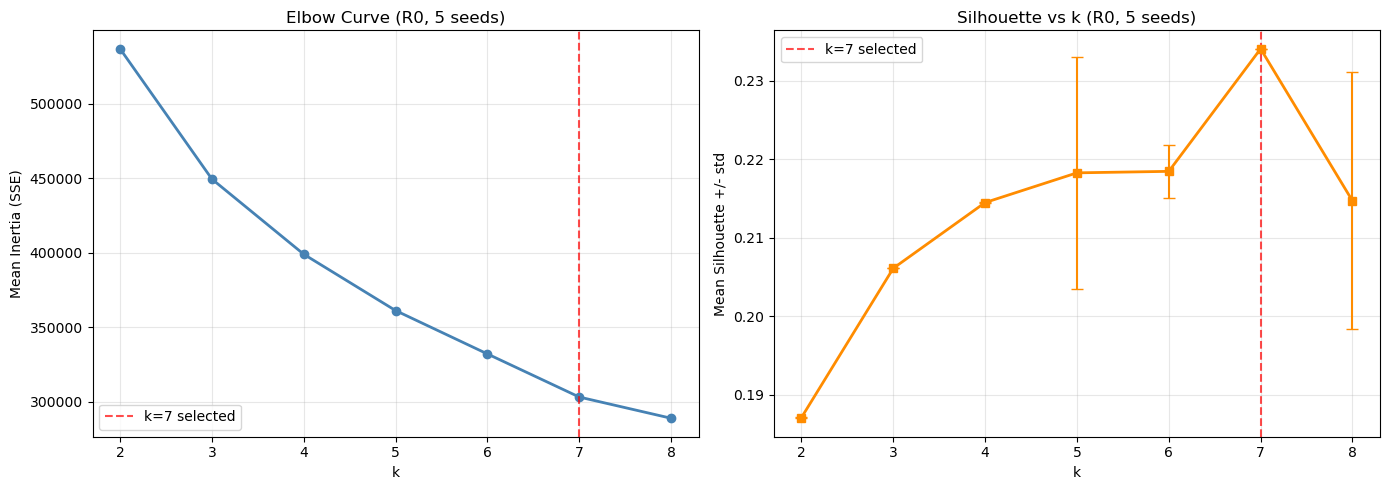

Saved: ../figures/k_selection_m2.png


In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_df['k'], k_df['mean_inertia'], 'o-', color='steelblue', lw=2)
ax1.axvline(K_SELECTED, color='red', ls='--', alpha=0.7,
            label=f'k={K_SELECTED} selected')
ax1.set(xlabel='k', ylabel='Mean Inertia (SSE)',
        title='Elbow Curve (R0, 5 seeds)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.errorbar(k_df['k'], k_df['mean_sil'], yerr=k_df['std_sil'],
             fmt='s-', color='darkorange', lw=2, capsize=4, elinewidth=1.5)
ax2.axvline(K_SELECTED, color='red', ls='--', alpha=0.7,
            label=f'k={K_SELECTED} selected')
ax2.set(xlabel='k', ylabel='Mean Silhouette +/- std',
        title='Silhouette vs k (R0, 5 seeds)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/k_selection_m2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figures/k_selection_m2.png')

In [36]:
# Final K-Means run on R0 (StandardScaler, no ADR)
t_R0 = time.perf_counter()
km_R0  = KMeans(n_clusters=K_SELECTED, random_state=RANDOM_STATE, n_init=10)
lbl_R0 = km_R0.fit_predict(X_R0)
t_R0 = time.perf_counter() - t_R0

df_clustering['cluster_R0'] = lbl_R0
m_R0 = metrics(X_R0, lbl_R0)

log_experiment(
    representation_id="R0",
    method="kmeans",
    parameters={"n_clusters": K_SELECTED, "n_init": 10},
    seed=RANDOM_STATE,
    sample_rule="full",
    metrics=m_R0,
    inertia=km_R0.inertia_,
    runtime_s=t_R0,
    notes="final run StandardScaler no ADR"
)

print(f'R0 (StandardScaler, no ADR):')
print(f'  Silhouette:        {m_R0["Silhouette"]:.4f}')
print(f'  Davies-Bouldin:    {m_R0["Davies-Bouldin"]:.4f}')
print(f'  Calinski-Harabasz: {m_R0["Calinski-Harabasz"]:.1f}')
print(f'  Inertia:           {km_R0.inertia_:.1f}')
print(f'  Runtime:           {t_R0:.4f}s')
print(f'  Cluster sizes:     {dict(pd.Series(lbl_R0).value_counts().sort_index())}')


R0 (StandardScaler, no ADR):
  Silhouette:        0.2341
  Davies-Bouldin:    1.3586
  Calinski-Harabasz: 22409.3
  Inertia:           303245.5
  Runtime:           1.9057s
  Cluster sizes:     {0: np.int64(19235), 1: np.int64(14052), 2: np.int64(10452), 3: np.int64(31299), 4: np.int64(19759), 5: np.int64(14444), 6: np.int64(10145)}


### 5.1 K-Means on R0 (StandardScaler, no ADR)

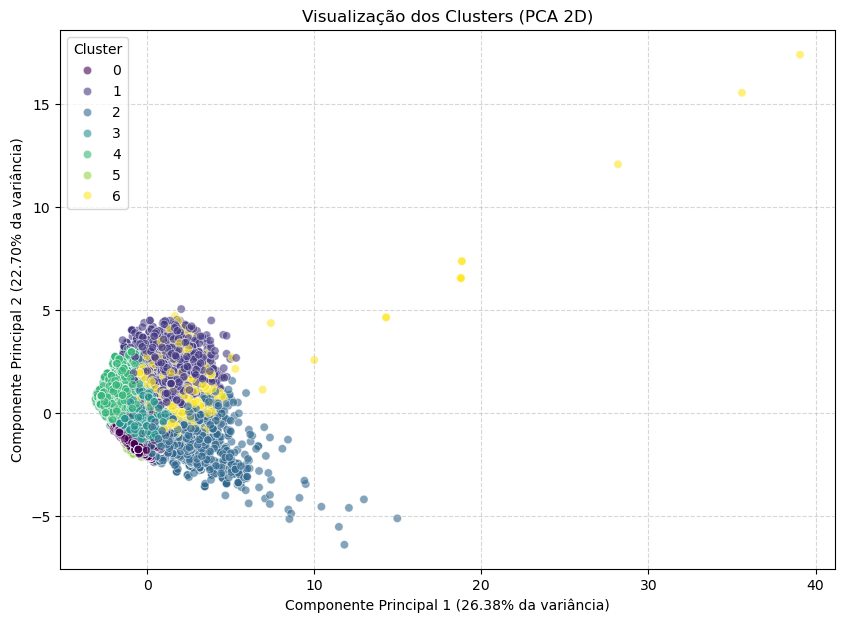

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_R0) # X_R0 são seus dados escalonados

# 2. Criar um DataFrame auxiliar para o plot
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = lbl_R0

# 3. Plotar
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='cluster', 
    data=df_pca, 
    palette='viridis',
    alpha=0.6,
    edgecolor='w'
)

plt.title('Visualização dos Clusters (PCA 2D)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} da variância)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [38]:
# Final K-Means run on R1 (RobustScaler, no ADR)
t_R1 = time.perf_counter()
km_R1  = KMeans(n_clusters=K_SELECTED, random_state=RANDOM_STATE, n_init=10)
lbl_R1 = km_R1.fit_predict(X_R1)
t_R1 = time.perf_counter() - t_R1

df_clustering['cluster_R1'] = lbl_R1
m_R1       = metrics(X_R1, lbl_R1)
ari_R0_R1  = adjusted_rand_score(lbl_R0, lbl_R1)

log_experiment(
    representation_id="R1",
    method="kmeans",
    parameters={"n_clusters": K_SELECTED, "n_init": 10},
    seed=RANDOM_STATE,
    sample_rule="full",
    metrics=m_R1,
    inertia=km_R1.inertia_,
    runtime_s=t_R1,
    notes="final run RobustScaler no ADR"
)

print(f'R1 (RobustScaler, no ADR):')
print(f'  Silhouette:        {m_R1["Silhouette"]:.4f}')
print(f'  Davies-Bouldin:    {m_R1["Davies-Bouldin"]:.4f}')
print(f'  Calinski-Harabasz: {m_R1["Calinski-Harabasz"]:.1f}')
print(f'  Inertia:           {km_R1.inertia_:.1f}')
print(f'  Runtime:           {t_R1:.4f}s')
print(f'  ARI(R0,R1):        {ari_R0_R1:.4f}')
print(f'  Cluster sizes:     {dict(pd.Series(lbl_R1).value_counts().sort_index())}')


R1 (RobustScaler, no ADR):
  Silhouette:        0.2381
  Davies-Bouldin:    1.3471
  Calinski-Harabasz: 24061.0
  Inertia:           256758.3
  Runtime:           2.0182s
  ARI(R0,R1):        0.7067
  Cluster sizes:     {0: np.int64(16002), 1: np.int64(19347), 2: np.int64(34964), 3: np.int64(12964), 4: np.int64(20261), 5: np.int64(1720), 6: np.int64(14128)}


In [39]:
df_profile = df.loc[df_clustering.index].copy()
df_profile['cluster'] = lbl_R0

df_profile['total_nights']  = df_profile['stays_in_week_nights'] + df_profile['stays_in_weekend_nights']
df_profile['party_size']    = df_profile['adults'] + df_profile['children'].fillna(0) + df_profile['babies']
df_profile['has_kids']      = ((df_profile['children'].fillna(0) + df_profile['babies']) > 0).astype(int)
df_profile['needs_parking'] = (df_profile['required_car_parking_spaces'] > 0).astype(int)

print("Numeric Profile")

numeric_profile_cols = [
    'adr', 'lead_time', 'total_nights', 'party_size',
    'total_of_special_requests', 'has_kids',
    'needs_parking', 'is_repeated_guest'
]

cluster_means = df_profile.groupby('cluster')[numeric_profile_cols].mean()
overall_mean = df_profile[numeric_profile_cols].mean()
overall_mean.name = 'dataset_mean'

difference_means = cluster_means.sub(overall_mean, axis=1)
difference_means.name = 'Means Difference'

difference_means_percentage = difference_means.div(overall_mean, axis=1).mul(100)
difference_means_percentage.name = 'Means Difference (%)'

print(pd.concat([cluster_means.round(3), overall_mean.round(3).to_frame().T]))
print("\nDifference vs dataset mean")
print(difference_means.round(3))


print("Categorical Profile")
profile_cat = ['market_segment', 'deposit_type', 'customer_type', 'meal']

with open('perfil_categorico_R0.txt', 'w') as f:
    for var in profile_cat:
        f.write(f"\n{var}:\n")
        ct = pd.crosstab(df_profile['cluster'], df_profile[var], normalize='index').mul(100).round(1)
        f.write(ct.to_string())
        f.write("\n" + "="*30 + "\n")

# Tamanhos
print("\nCluster Size")
print(df_profile['cluster'].value_counts().sort_index())

Numeric Profile
                  adr  lead_time  total_nights  party_size  total_of_special_requests  has_kids  needs_parking  \
0              84.042    149.486         2.868       1.725                      0.192     0.002          0.022   
1             117.713     91.235         3.573       2.162                      2.231     0.135          0.090   
2              98.592    136.799         9.049       1.966                      0.500     0.035          0.053   
3             104.361     87.169         3.187       1.907                      0.493     0.005          0.056   
4              84.517      3.823         1.750       1.537                      0.367     0.013          0.125   
5              89.479    216.035         2.662       1.812                      0.001     0.000          0.001   
6             159.908     89.328         3.598       3.414                      0.520     0.654          0.093   
dataset_mean  101.789    104.013         3.428       1.968              

In [40]:
print("\nDifference vs dataset mean (%)")
print(difference_means_percentage.round(3))


Difference vs dataset mean (%)
            adr  lead_time  total_nights  party_size  total_of_special_requests  has_kids  needs_parking  \
cluster                                                                                                    
0       -17.436     43.719       -16.323     -12.367                    -66.379   -97.473        -65.016   
1        15.644    -12.285         4.244       9.843                    290.474    73.070         45.381   
2        -3.140     31.521       163.972      -0.107                    -12.573   -55.202        -14.826   
3         2.527    -16.194        -7.015      -3.087                    -13.761   -94.155        -10.196   
4       -16.968    -96.325       -48.960     -21.934                    -35.843   -84.008        101.404   
5       -12.094    107.700       -22.349      -7.922                    -99.879  -100.000        -98.774   
6        57.097    -14.118         4.957      73.445                     -9.064   736.948         50.273

### 5.2 K-Means on R1 (RobustScaler, no ADR)

In [41]:
df_profile = df.loc[df_clustering.index].copy()
df_profile['cluster'] = lbl_R1

df_profile['total_nights']  = df_profile['stays_in_week_nights'] + df_profile['stays_in_weekend_nights']
df_profile['party_size']    = df_profile['adults'] + df_profile['children'].fillna(0) + df_profile['babies']
df_profile['has_kids']      = ((df_profile['children'].fillna(0) + df_profile['babies']) > 0).astype(int)
df_profile['needs_parking'] = (df_profile['required_car_parking_spaces'] > 0).astype(int)

print("Numeric Profile")

numeric_profile_cols = [
    'adr', 'lead_time', 'total_nights', 'party_size',
    'total_of_special_requests', 'has_kids',
    'needs_parking', 'is_repeated_guest'
]

cluster_means = df_profile.groupby('cluster')[numeric_profile_cols].mean()
overall_mean = df_profile[numeric_profile_cols].mean()
overall_mean.name = 'dataset_mean'

difference_means = cluster_means.sub(overall_mean, axis=1)
difference_means.name = 'Means Difference'

difference_means_percentage = difference_means.div(overall_mean, axis=1).mul(100)
difference_means_percentage.name = 'Means Difference (%)'

print(pd.concat([cluster_means.round(3), overall_mean.round(3).to_frame().T]))
print("\nDifference vs dataset mean")
print(difference_means.round(3))


print("Categorical Profile")
profile_cat = ['market_segment', 'deposit_type', 'customer_type', 'meal']

with open('perfil_categorico_R1.txt', 'w') as f:
    for var in profile_cat:
        f.write(f"\n{var}:\n")
        ct = pd.crosstab(df_profile['cluster'], df_profile[var], normalize='index').mul(100).round(1)
        f.write(ct.to_string())
        f.write("\n" + "="*30 + "\n")

# Tamanhos
print("\nCluster Size")
print(df_profile['cluster'].value_counts().sort_index())

Numeric Profile
                  adr  lead_time  total_nights  party_size  total_of_special_requests  has_kids  needs_parking  \
0             106.876    130.213         7.156       2.124                      0.566     0.113          0.061   
1              85.412    141.318         2.651       1.735                      0.221     0.008          0.025   
2             115.977     87.869         3.084       2.220                      0.483     0.128          0.061   
3             120.615     85.349         3.202       2.235                      2.241     0.167          0.090   
4              86.029      5.536         1.549       1.572                      0.386     0.029          0.127   
5              93.348    147.130        15.663       1.965                      0.639     0.074          0.044   
6              89.696    216.306         2.534       1.812                      0.001     0.000          0.001   
dataset_mean  101.789    104.013         3.428       1.968              

In [42]:
print("\nDifference vs dataset mean (%)")
print(difference_means_percentage.round(3))


Difference vs dataset mean (%)
            adr  lead_time  total_nights  party_size  total_of_special_requests  has_kids  needs_parking  \
cluster                                                                                                    
0         4.997     25.189       108.748       7.933                     -0.895    45.184         -1.711   
1       -16.089     35.866       -22.673     -11.860                    -61.317   -89.552        -59.810   
2        13.939    -15.521       -10.040      12.796                    -15.518    63.775         -2.343   
3        18.495    -17.944        -6.592      13.575                    292.301   114.042         45.164   
4       -15.483    -94.678       -54.820     -20.155                    -32.387   -63.062        105.154   
5        -8.293     41.454       356.938      -0.158                     11.831    -5.539        -29.803   
6       -11.880    107.961       -26.068      -7.945                    -99.827   -99.909        -98.974

### 5.3 K-Means on R2 (StandardScaler, with ADR)

In [44]:
# Final K-Means run on R2 (StandardScaler, with ADR)
t_R2 = time.perf_counter()
km_R2  = KMeans(n_clusters=K_SELECTED, random_state=RANDOM_STATE, n_init=10)
lbl_R2 = km_R2.fit_predict(X_R2)
t_R2 = time.perf_counter() - t_R2

df_profile = df.loc[df_clustering.index].copy()
df_profile['cluster'] = lbl_R2

df_profile['total_nights']  = df_profile['stays_in_week_nights'] + df_profile['stays_in_weekend_nights']
df_profile['party_size']    = df_profile['adults'] + df_profile['children'].fillna(0) + df_profile['babies']
df_profile['has_kids']      = ((df_profile['children'].fillna(0) + df_profile['babies']) > 0).astype(int)
df_profile['needs_parking'] = (df_profile['required_car_parking_spaces'] > 0).astype(int)

print("Numeric Profile")

numeric_profile_cols = [
    'adr', 'lead_time', 'total_nights', 'party_size',
    'total_of_special_requests', 'has_kids',
    'needs_parking', 'is_repeated_guest'
]

cluster_means = df_profile.groupby('cluster')[numeric_profile_cols].mean()
overall_mean = df_profile[numeric_profile_cols].mean()
overall_mean.name = 'dataset_mean'

difference_means = cluster_means.sub(overall_mean, axis=1)
difference_means.name = 'Means Difference'

difference_means_percentage = difference_means.div(overall_mean, axis=1).mul(100)
difference_means_percentage.name = 'Means Difference (%)'

print(pd.concat([cluster_means.round(3), overall_mean.round(3).to_frame().T]))
print("\nDifference vs dataset mean")
print(difference_means.round(3))


print("Categorical Profile")
profile_cat = ['market_segment', 'deposit_type', 'customer_type', 'meal']

with open('perfil_categorico_R2.txt', 'w') as f:
    for var in profile_cat:
        f.write(f"\n{var}:\n")
        ct = pd.crosstab(df_profile['cluster'], df_profile[var], normalize='index').mul(100).round(1)
        f.write(ct.to_string())
        f.write("\n" + "="*30 + "\n")

# Tamanhos
print("\nCluster Size")
print(df_profile['cluster'].value_counts().sort_index())

Numeric Profile
                  adr  lead_time  total_nights  party_size  total_of_special_requests  has_kids  needs_parking  \
0              76.681      4.208         1.747       1.522                      0.361     0.017          0.125   
1              79.985    149.260         2.858       1.728                      0.179     0.007          0.022   
2             187.747     83.506         3.802       3.214                      0.626     0.540          0.114   
3              89.785    216.362         2.667       1.817                      0.001     0.000          0.000   
4             114.006     92.145         3.554       2.130                      2.236     0.120          0.085   
5              90.378    138.692         9.074       1.960                      0.506     0.043          0.047   
6             104.623     86.979         3.181       1.958                      0.510     0.026          0.054   
dataset_mean  101.789    104.013         3.428       1.968              

In [45]:
print("\nDifference vs dataset mean (%)")
print(difference_means_percentage.round(3))


Difference vs dataset mean (%)
            adr  lead_time  total_nights  party_size  total_of_special_requests  has_kids  needs_parking  \
cluster                                                                                                    
0       -24.667    -95.955       -49.036     -22.652                    -36.853   -78.658        100.714   
1       -21.421     43.501       -16.611     -12.224                    -68.611   -91.669        -64.435   
2        84.447    -19.715        10.919      63.294                      9.596   590.686         83.990   
3       -11.793    108.014       -22.186      -7.689                    -99.890   -99.732        -99.888   
4        12.002    -11.410         3.666       8.201                    291.384    53.213         36.757   
5       -11.210     33.341       164.705      -0.420                    -11.402   -45.101        -24.361   
6         2.784    -16.377        -7.199      -0.537                    -10.707   -66.342        -13.690

### 5.4 iK-Means

In [48]:
FloatArray = NDArray[np.float64]
@dataclass(frozen=True)
class APCluster:
    indices: list[int]
    centroid_raw: FloatArray
    centroid_std: FloatArray
    size: int
    scatter_pct: float
    
def compute_feature_statistics(
    X: FloatArray, use_unit_ranges: bool = False
        ) -> tuple[FloatArray, FloatArray, float]:
    
    means = X.mean(axis=0) # one mean per line of floats
    
    if use_unit_ranges:
        ranges = np.ones(shape=X.shape[1], dtype=np.float64)
    else:
        max_vals = X.max(axis=0)
        min_vals = X.min(axis=0)
        ranges = max_vals - min_vals
        # when ranges == 0, we are to replace with 1
        ranges[ranges==0.0] = 1.0
    
    # D is the sum of normalized square distances of X
    Yi = (X - means) / ranges
    D = float(np.sum(Yi ** 2))  
    
    return means, ranges, D
    

def normalized_squared_distances(
    X: FloatArray, indices: list[int],
    scales: FloatArray, reference: FloatArray,
        ) -> FloatArray:
    
    rows = X[indices] 
    dist = (rows - reference) / scales 
    return np.sum(dist ** 2, axis=1) # float array list of sum per column

    
def cluster_centroid(
    X: FloatArray, indices: list[int],
        ) -> FloatArray:
    
    # the centroid are the means of each indice line of X
    return X[indices].mean(axis=0)
    
def separate_cluster(
    X: FloatArray, indices: list[int],
    scales: FloatArray, a: FloatArray, b: FloatArray,
        ) -> list[int]:
    
    # compute distances for references a and b
    dist_a = normalized_squared_distances(X, indices, scales, reference=a)
    dist_b = normalized_squared_distances(X, indices, scales, reference=b)
    
    # list of True False values where is True when dist_a < dist_b
    closer_to_a = dist_a < dist_b
    
    #outputs list of index where it is closer to a than to b
    return [index for index, closer in zip(indices, closer_to_a) if closer]
    
    
def extract_anomalous_cluster(
    X: FloatArray, indices: list[int],
    scales: FloatArray, mean: FloatArray,
    initial_centroid: FloatArray, seed_index: int,
    tol: float = 1e-12, max_iter: int = 10_000,
        ) -> tuple[list[int], FloatArray]:
    
    c = initial_centroid
    S_prev = []
 
    for _ in range(max_iter):
        
        S = separate_cluster(X, indices, scales, c, mean)
 
        if not S:
            S = [seed_index]
 
        c_new = cluster_centroid(X, S)
 
        if (S == S_prev) or (np.linalg.norm(c_new - c) <= tol):
            return S, c_new
 
        c = c_new
        S_prev = S
 
    return S if S_prev else [seed_index], c

    
def ikmeans_initialize(
    X: FloatArray, min_cluster_size: int,
    tol: float = 1e-12, max_iter: int = 10_000, use_unit_ranges: bool = False,
        ) -> tuple[list[APCluster], FloatArray]:
 
    mean, scales, D = compute_feature_statistics(X, use_unit_ranges)
 
    remains = list(range(X.shape[0]))
    ap_clusters = []
 
    while remains:
        dists = normalized_squared_distances(X, remains, scales, mean)
        
        q = remains[int(np.argmax(dists))]
        
        seed = X[q,:]
 
        S, c = extract_anomalous_cluster(
            X, remains, scales, mean,
            initial_centroid=seed,
            seed_index=q,
            tol=tol,
            max_iter=max_iter,
        )
 
        z = (c - mean) / scales
 
        if D > 0.0:
            scatter_pct = 100.0 * len(S) * float(np.sum(z ** 2)) / D
        else:
            scatter_pct = 0.0
 
        ap_clusters.append(APCluster(
            indices = S, centroid_raw = c, centroid_std = z, 
            size = len(S), scatter_pct = scatter_pct,
        ))

        # remains is remains except S
        remains = [index for index in remains if index not in S]
    
    # retain records with size bigger or equal than the minimum
    retained = [record for record in ap_clusters if record.size >= min_cluster_size]
 
    if not retained:
        raise ValueError("No anomalous cluster satisfies the minimum size.")
 
    init_centroids = np.vstack([record.centroid_std for record in retained])
 
    return ap_clusters, init_centroids


In [ ]:
min_sizes = range(1000, 5000, 500)
sweep_results = []

print(f"{'min_cluster_size':>18} {'k':>5} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20}")
print("-" * 75)

for min_cluster_size in min_sizes:
    ap_clusters, init_centroids = ikmeans_initialize(
        X_R0,
        min_cluster_size=min_cluster_size,
        use_unit_ranges=True
    )

    k = init_centroids.shape[0]

    if k < 2:
        print(f"{min_cluster_size:>18} {'<2 clusters, skipped':>55}")
        continue

    t0 = time.perf_counter()
    km = KMeans(n_clusters=k, init=init_centroids, n_init=1)
    labels = km.fit_predict(X_R0)
    t_elapsed = time.perf_counter() - t0

    m = metrics(X_R0, labels)

    log_experiment(
        representation_id="R0",
        method="ikmeans",
        parameters={"min_cluster_size": min_cluster_size, "use_unit_ranges": True, "n_clusters": k},
        seed=None,
        sample_rule="full",
        metrics=m,
        inertia=km.inertia_,
        runtime_s=t_elapsed,
        notes=f"ikmeans_sweep min_size={min_cluster_size}"
    )

    sweep_results.append({
        'k': k,
        'min_size': min_cluster_size,
        'mean_sil': m['Silhouette'],
        'mean_cals': m['Calinski-Harabasz'],
        'mean_davies': m['Davies-Bouldin'],
    })

    print(f"{min_cluster_size:>18} {k:>5} {m['Silhouette']:>12.4f} "
          f"{m['Davies-Bouldin']:>16.4f} {m['Calinski-Harabasz']:>20.1f}")

best_k, votes, winners = decide_best_k(sweep_results)

print("\nVotes per k:")
for r in sweep_results:
    print(f"  min_size={r['min_size']:>6}  k={r['k']:>3}  votes={votes[r['k']]}")

print(f"\nPer-metric winners: {winners}")
print(f"Best k (majority vote): {best_k}")

best_run = next(r for r in sweep_results if r['k'] == best_k)
print(f"\nBest configuration:")
print(f"  min_cluster_size : {best_run['min_size']}")
print(f"  k                : {best_run['k']}")
print(f"  Silhouette       : {best_run['mean_sil']:.4f}")
print(f"  Davies-Bouldin   : {best_run['mean_davies']:.4f}")
print(f"  Calinski-Harabasz: {best_run['mean_cals']:.1f}")


  min_cluster_size     k   Silhouette   Davies-Bouldin    Calinski-Harabasz
---------------------------------------------------------------------------
              1000     9       0.2027           1.4387              19364.7
              1500     9       0.2027           1.4387              19364.7
              2000     8       0.2183           1.4328              19608.4
              2500     8       0.2183           1.4328              19608.4
              3000     6       0.1740           1.5208              21540.0
              3500     6       0.1740           1.5208              21540.0
              4000     6       0.1740           1.5208              21540.0
              4500     6       0.1740           1.5208              21540.0

Votes per k:
  min_size=  1000  k=  9  votes=0
  min_size=  1500  k=  9  votes=0
  min_size=  2000  k=  8  votes=2
  min_size=  2500  k=  8  votes=2
  min_size=  3000  k=  6  votes=1
  min_size=  3500  k=  6  votes=1
  min_size=  4000  k= 

In [50]:
min_sizes_k7 = [2850]  
sweep_results_k7 = []

print(f"\n{'min_cluster_size':>18} {'k':>5} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20}")
print("-" * 75)

for min_cluster_size in min_sizes_k7:
    ap_clusters, init_centroids = ikmeans_initialize(
        X_R0,
        min_cluster_size=min_cluster_size,
        use_unit_ranges=True
    )
    k = init_centroids.shape[0]
    if k < 2:
        print(f"{min_cluster_size:>18} {'<2 clusters, skipped':>55}")
        continue
    km = KMeans(n_clusters=k, init=init_centroids, n_init=1)
    labels = km.fit_predict(X_R0)
    m = metrics(X_R0, labels)
    sweep_results_k7.append({
        'k':            k,
        'min_size':     min_cluster_size,
        'mean_sil':     m['Silhouette'],
        'mean_cals':    m['Calinski-Harabasz'],
        'mean_davies':  m['Davies-Bouldin'],
        'mean_inertia': km.inertia_,
        'labels':       labels,
    })
    print(f"{min_cluster_size:>18} {k:>5} {m['Silhouette']:>12.4f} "
          f"{m['Davies-Bouldin']:>16.4f} {m['Calinski-Harabasz']:>20.1f}")

best_run_k7 = sweep_results_k7[0]


  min_cluster_size     k   Silhouette   Davies-Bouldin    Calinski-Harabasz
---------------------------------------------------------------------------
              2850     7       0.2172           1.3795              21550.3


In [ ]:
# from k_results on multiple seeds
run_k8_rnd = next(r for r in k_results if r['k'] == 8)
run_k7_rnd = next(r for r in k_results if r['k'] == 7)


print(f"\nStability comparison | iK-Means k=8 vs iK-Means k=7 vs Random k=8 vs Random k=7\n")
print(f"{'Method':<25} {'Sil (mean)':>10} {'Sil (std)':>10} {'Davies (mean)':>14} {'Davies (std)':>12} {'Calinski (mean)':>16} {'Calinski (std)':>14}")
print("-" * 110)

print(f"{'iK-Means k=8 (det.)':<25} "
      f"{best_run['mean_sil']:>10.4f} {'N/A':>10} "
      f"{best_run['mean_davies']:>14.4f} {'N/A':>12} "
      f"{best_run['mean_cals']:>16.1f} {'N/A':>14} ")

print(f"{'Random init k=8':<25} "
      f"{run_k8_rnd['mean_sil']:>10.4f} {run_k8_rnd['std_sil']:>10.4f} "
      f"{run_k8_rnd['mean_davies']:>14.4f} {run_k8_rnd['std_davies']:>12.4f} "
      f"{run_k8_rnd['mean_cals']:>16.1f} {run_k8_rnd['std_cals']:>14.1f} ")

if 'best_run_k7' in locals() and best_run_k7 is not None:
    print(f"{'iK-Means k=7 (det.)':<25} "
          f"{best_run_k7['mean_sil']:>10.4f} {'N/A':>10} "
          f"{best_run_k7['mean_davies']:>14.4f} {'N/A':>12} "
          f"{best_run_k7['mean_cals']:>16.1f} {'N/A':>14} ")
else:
    print(f"{'iK-Means k=7 (det.)':<25} {'N/A':>10} {'N/A':>10} {'N/A':>14} {'N/A':>12} {'N/A':>16} {'N/A':>14} ")

print(f"{'Random init k=7':<25} "
      f"{run_k7_rnd['mean_sil']:>10.4f} {run_k7_rnd['std_sil']:>10.4f} "
      f"{run_k7_rnd['mean_davies']:>14.4f} {run_k7_rnd['std_davies']:>12.4f} "
      f"{run_k7_rnd['mean_cals']:>16.1f} {run_k7_rnd['std_cals']:>14.1f} ")

# Majority vote across all four
comparison_results = [
    {
        'k':           'iK-Means_k8',
        'mean_sil':    best_run['mean_sil'],
        'mean_cals':   best_run['mean_cals'],
        'mean_davies': best_run['mean_davies'],
    },
    {
        'k':           'Random_k8',
        'mean_sil':    run_k8_rnd['mean_sil'],
        'mean_cals':   run_k8_rnd['mean_cals'],
        'mean_davies': run_k8_rnd['mean_davies'],
        'std_sil':     run_k8_rnd['std_sil'],
        'std_cals':    run_k8_rnd['std_cals'],
        'std_davies':  run_k8_rnd['std_davies'],
    },
]

if 'best_run_k7' in locals() and best_run_k7 is not None:
    comparison_results.append({
        'k':           'iK-Means_k7',
        'mean_sil':    best_run_k7['mean_sil'],
        'mean_cals':   best_run_k7['mean_cals'],
        'mean_davies': best_run_k7['mean_davies'],
    })

comparison_results.append({
    'k':           'Random_k7',
    'mean_sil':    run_k7_rnd['mean_sil'],
    'mean_cals':   run_k7_rnd['mean_cals'],
    'mean_davies': run_k7_rnd['mean_davies'],
    'std_sil':     run_k7_rnd['std_sil'],
    'std_cals':    run_k7_rnd['std_cals'],
    'std_davies':  run_k7_rnd['std_davies'],
})

best_method, votes, winners = decide_best_k(comparison_results)
print(f"\nVotes: {votes}")
print(f"Per-metric winners: {winners}")
print(f"Majority vote winner: {best_method}")

Using k=8 result from iK-Means sweep (min_size=2000)

Stability comparison | iK-Means k=8 vs iK-Means k=7 vs Random k=8 vs Random k=7

Method                    Sil (mean)  Sil (std)  Davies (mean) Davies (std)  Calinski (mean) Calinski (std)
--------------------------------------------------------------------------------------------------------------
iK-Means k=8 (det.)           0.2183        N/A         1.4328          N/A          19608.4            N/A 
Random init k=8               0.2147     0.0164         1.3899       0.0347          20994.9           96.2 
iK-Means k=7 (det.)           0.2172        N/A         1.3795          N/A          21550.3            N/A 
Random init k=7               0.2341     0.0000         1.3586       0.0000          22409.3            0.0 

Votes: {'iK-Means_k8': 0, 'Random_k8': 0, 'iK-Means_k7': 0, 'Random_k7': 3}
Per-metric winners: {'silhouette_winner': 'Random_k7', 'calinski_winner': 'Random_k7', 'davies_bouldin_winner': 'Random_k7'}
Majority